In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import shutil
import random
import numpy as np
from skimage import io
from PIL import Image
from keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from keras.preprocessing.image import ImageDataGenerator
from ast import main
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

train_dir = '/content/drive/MyDrive/017'

batch_size = 8
image_size = (224, 224)

# Increase the amount of augmentation
datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,  # Rotate images randomly up to 20 degrees
    width_shift_range=0.2,  # Shift width of images randomly up to 20%
    height_shift_range=0.2,  # Shift height of images randomly up to 20%
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',  # Fill mode for filling in newly created pixels
    validation_split=0.2  # Split 20% of the data for validation
)


train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'  # Use the training split
)

validation_generator = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'  # Use the validation split
)

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [ ]:
import os
import shutil
import random
import numpy as np
from skimage import io
from PIL import Image
from keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from keras.preprocessing.image import ImageDataGenerator
from ast import main
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout,Dense, Flatten,BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adadelta,Adam,SGD,RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential

In [ ]:
# Load MobileNetV2 base model
base_model = DenseNet121(weights='imagenet',
                         include_top=False,
                         input_shape=(224, 224, 3))

# Add custom layers on top
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)  # Add more dense layers if needed
output = Dense(1, activation='sigmoid')(x)  # Binary classification, so use sigmoid activation

# Create the model
model = Model(inputs=base_model.input, outputs=output)

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Adjust the paths and parameters accordingly
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

29084464/29084464 [==============================] - 0s 0us/step
Epoch 1/30
50/50 [==============================] - 150s 3s/step - loss: 0.3617 - accuracy: 0.8450 - val_loss: 0.1621 - val_accuracy: 0.9600
Epoch 2/30
50/50 [==============================] - 83s 2s/step - loss: 0.1674 - accuracy: 0.9450 - val_loss: 0.1106 - val_accuracy: 0.9700
Epoch 3/30
50/50 [==============================] - 81s 2s/step - loss: 0.1010 - accuracy: 0.9600 - val_loss: 0.1177 - val_accuracy: 0.9500
Epoch 4/30
50/50 [==============================] - 82s 2s/step - loss: 0.0762 - accuracy: 0.9775 - val_loss: 0.0765 - val_accuracy: 0.9800
Epoch 5/30
50/50 [==============================] - 79s 2s/step - loss: 0.0733 - accuracy: 0.9775 - val_loss: 0.0829 - val_accuracy: 0.9700
Epoch 6/30
50/50 [==============================] - 81s 2s/step - loss: 0.0584 - accuracy: 0.9850 - val_loss: 0.0911 - val_accuracy: 0.9600
Epoch 7/30
50/50 [==============================] - 77s 2s/step - loss: 0.0782 - accuracy: 0.9

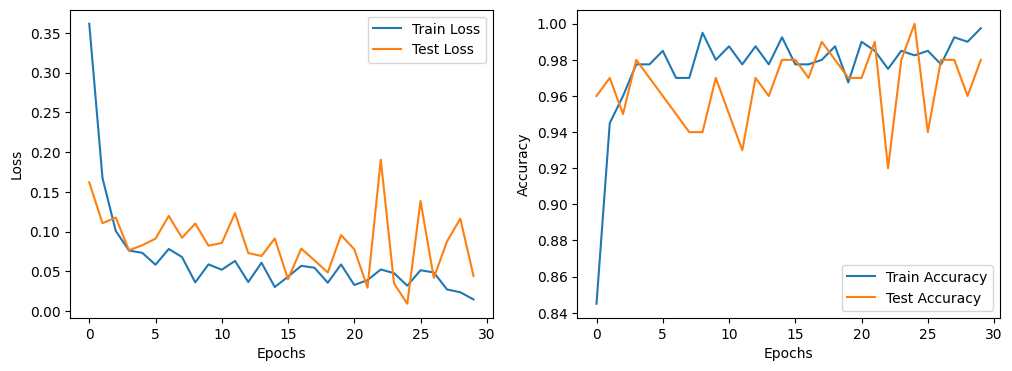

In [ ]:
# Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
predictions = model.predict(validation_generator)
y_true = validation_generator.classes
y_pred = predictions.argmax(axis=-1)
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy *100:.2f}%")

13/13 [==============================] - 24s 2s/step
Accuracy: 50.00%


1/1 [==============================] - 1s 515ms/step


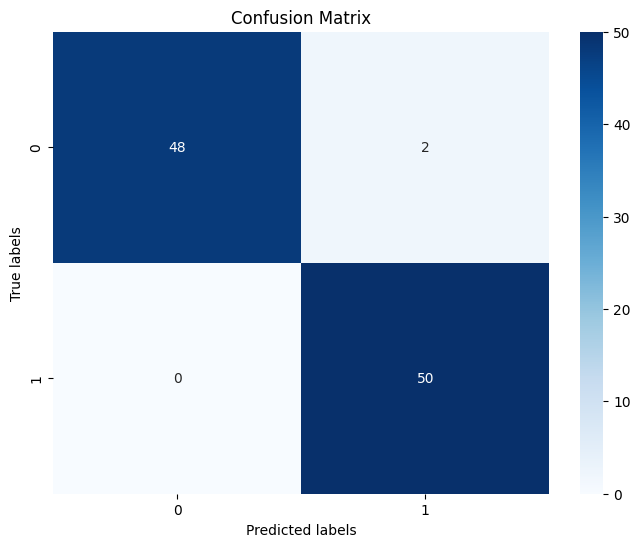


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98        50
         1.0       0.96      1.00      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [ ]:
# Evaluate the model using confusion matrix and classification report
validation_steps = len(validation_generator)
y_true = []
y_pred = []
for i in range(validation_steps):
    images, labels = validation_generator[i]
    y_true.extend(labels)
    y_pred.extend(model.predict(images).flatten() > 0.5)

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

# Assuming y_true and y_pred are defined
# Calculate the confusion matrix
confusion_matrix_data = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_data, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

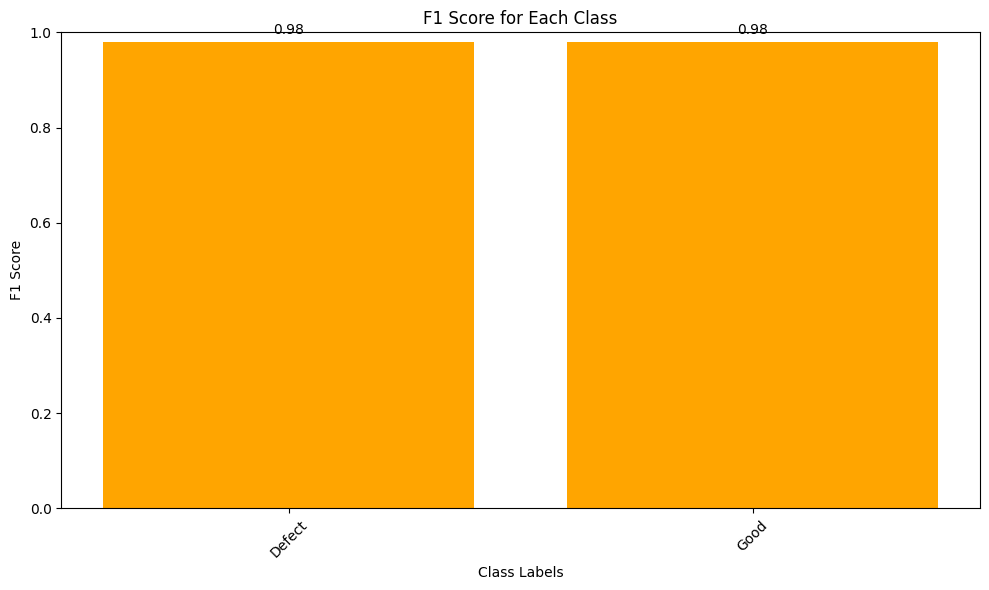

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Calculate F1 scores for each class
f1_scores = f1_score(y_true, y_pred, average=None)

# Get class labels
class_labels = list(validation_generator.class_indices.keys())

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(class_labels, f1_scores, color='Orange')
plt.xlabel('Class Labels')
plt.ylabel('F1 Score')
plt.title('F1 Score for Each Class')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Set y-axis limit to the range of F1 scores (0 to 1)

# Annotate each bar with its corresponding F1 score
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, round(score, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()
